In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

PROCESSED_DATA_PATH = Path("../data/processed")

print("NEXUS EDA Started ")

NEXUS EDA Started 🚀


In [2]:
# Load core datasets

customers = pd.read_csv(
    PROCESSED_DATA_PATH / "customers.csv"
)

products = pd.read_csv(
    PROCESSED_DATA_PATH / "products.csv"
)

orders = pd.read_csv(
    PROCESSED_DATA_PATH / "orders.csv",
    parse_dates=["order_date"]
)

order_items = pd.read_csv(
    PROCESSED_DATA_PATH / "order_items.csv"
)

payments = pd.read_csv(
    PROCESSED_DATA_PATH / "payments.csv"
)

warehouses = pd.read_csv(
    PROCESSED_DATA_PATH / "warehouses.csv"
)

inventory = pd.read_csv(
    PROCESSED_DATA_PATH / "inventory.csv"
)

deliveries = pd.read_csv(
    PROCESSED_DATA_PATH / "deliveries.csv",
    parse_dates=[
        "shipped_date",
        "expected_delivery",
        "actual_delivery"
    ]
)

returns = pd.read_csv(
    PROCESSED_DATA_PATH / "returns.csv",
    parse_dates=["return_date"]
)

print("All NEXUS datasets loaded successfully.")

All NEXUS datasets loaded successfully.


In [3]:
# Dataset overview

datasets = {
    "Customers": customers,
    "Products": products,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Warehouses": warehouses,
    "Inventory": inventory,
    "Deliveries": deliveries,
    "Returns": returns
}

for name, df in datasets.items():
    print(f"{name:15} → {df.shape[0]:>8,} rows × {df.shape[1]} columns")

Customers       →   10,000 rows × 10 columns
Products        →      500 rows × 8 columns
Orders          →   50,000 rows × 8 columns
Order Items     →  149,928 rows × 6 columns
Payments        →   50,000 rows × 6 columns
Warehouses      →       20 rows × 6 columns
Inventory       →   10,000 rows × 6 columns
Deliveries      →   50,000 rows × 8 columns
Returns         →    4,000 rows × 7 columns


In [4]:
# Total Revenue

total_revenue = orders.loc[
    orders["order_status"] != "Cancelled",
    "total_amount"
].sum()

print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹1,044,313,910.45


In [5]:
# Total Orders

total_orders = orders["order_id"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 50,000


In [6]:
# Average Order Value

average_order_value = (
    orders.loc[
        orders["order_status"] != "Cancelled",
        "total_amount"
    ].mean()
)

print(f"Average Order Value: ₹{average_order_value:,.2f}")

Average Order Value: ₹25,030.29


In [7]:
# Total Units Sold

total_units_sold = order_items["quantity"].sum()

print(f"Total Units Sold: {total_units_sold:,}")

Total Units Sold: 449,075


In [8]:
# Total Discount

total_discount = orders.loc[
    orders["order_status"] != "Cancelled",
    "discount_amount"
].sum()

print(f"Total Discount Given: ₹{total_discount:,.2f}")

Total Discount Given: ₹104,223,943.83


In [9]:
# Total Shipping Cost

total_shipping_cost = orders.loc[
    orders["order_status"] != "Cancelled",
    "shipping_cost"
].sum()

print(f"Total Shipping Cost: ₹{total_shipping_cost:,.2f}")

Total Shipping Cost: ₹11,248,082.73


In [10]:
# Estimated Gross Profit

profit_data = order_items.merge(
    products[["product_id", "unit_cost"]],
    on="product_id",
    how="left"
)

profit_data["revenue"] = (
    profit_data["unit_price"] * profit_data["quantity"]
)

profit_data["cost"] = (
    profit_data["unit_cost"] * profit_data["quantity"]
)

profit_data["gross_profit"] = (
    profit_data["revenue"] - profit_data["cost"]
)

total_gross_profit = profit_data["gross_profit"].sum()

print(f"Estimated Gross Profit: ₹{total_gross_profit:,.2f}")

Estimated Gross Profit: ₹1,678,387,012.74


In [11]:
# Net Revenue

valid_orders = orders[
    orders["order_status"] != "Cancelled"
]

gross_revenue = valid_orders["total_amount"].sum()
total_discount = valid_orders["discount_amount"].sum()

net_revenue = gross_revenue - total_discount

print(f"Gross Revenue: ₹{gross_revenue:,.2f}")
print(f"Discounts: ₹{total_discount:,.2f}")
print(f"Net Revenue: ₹{net_revenue:,.2f}")

Gross Revenue: ₹1,044,313,910.45
Discounts: ₹104,223,943.83
Net Revenue: ₹940,089,966.62


In [12]:
# Return Rate

total_returned_orders = returns["order_id"].nunique()

return_rate = (
    total_returned_orders / total_orders
) * 100

print(f"Returned Orders: {total_returned_orders:,}")
print(f"Return Rate: {return_rate:.2f}%")

Returned Orders: 4,000
Return Rate: 8.00%


In [13]:
# Delivery Delay Analysis

total_deliveries = deliveries["delivery_id"].nunique()

delayed_deliveries = deliveries[
    deliveries["delivery_delay_days"] > 0
]["delivery_id"].nunique()

delay_rate = (
    delayed_deliveries / total_deliveries
) * 100

average_delay = deliveries[
    deliveries["delivery_delay_days"] > 0
]["delivery_delay_days"].mean()

print(f"Total Deliveries: {total_deliveries:,}")
print(f"Delayed Deliveries: {delayed_deliveries:,}")
print(f"Delay Rate: {delay_rate:.2f}%")
print(f"Average Delay: {average_delay:.2f} days")

Total Deliveries: 50,000
Delayed Deliveries: 28,523
Delay Rate: 57.05%
Average Delay: 2.50 days


In [14]:
# Monthly Revenue Trend

valid_orders = orders[
    orders["order_status"] != "Cancelled"
].copy()

valid_orders["month"] = (
    valid_orders["order_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_revenue = (
    valid_orders
    .groupby("month")["total_amount"]
    .sum()
    .reset_index()
)

print(monthly_revenue)

      month  total_amount
0   2024-09    5581801.65
1   2024-10   44741211.58
2   2024-11   43445859.83
3   2024-12   43907079.47
4   2025-01   47080426.19
5   2025-02   40571740.45
6   2025-03   42576379.32
7   2025-04   41723479.46
8   2025-05   41979590.68
9   2025-06   41167865.76
10  2025-07   43410257.16
11  2025-08   44162040.65
12  2025-09   44295651.32
13  2025-10   45509373.08
14  2025-11   42699835.94
15  2025-12   44651376.13
16  2026-01   44067822.38
17  2026-02   40635806.71
18  2026-03   45367553.90
19  2026-04   42140289.66
20  2026-05   43755964.99
21  2026-06   43064720.39
22  2026-07   44001817.65
23  2026-08   46160504.37
24  2026-09   37615461.73


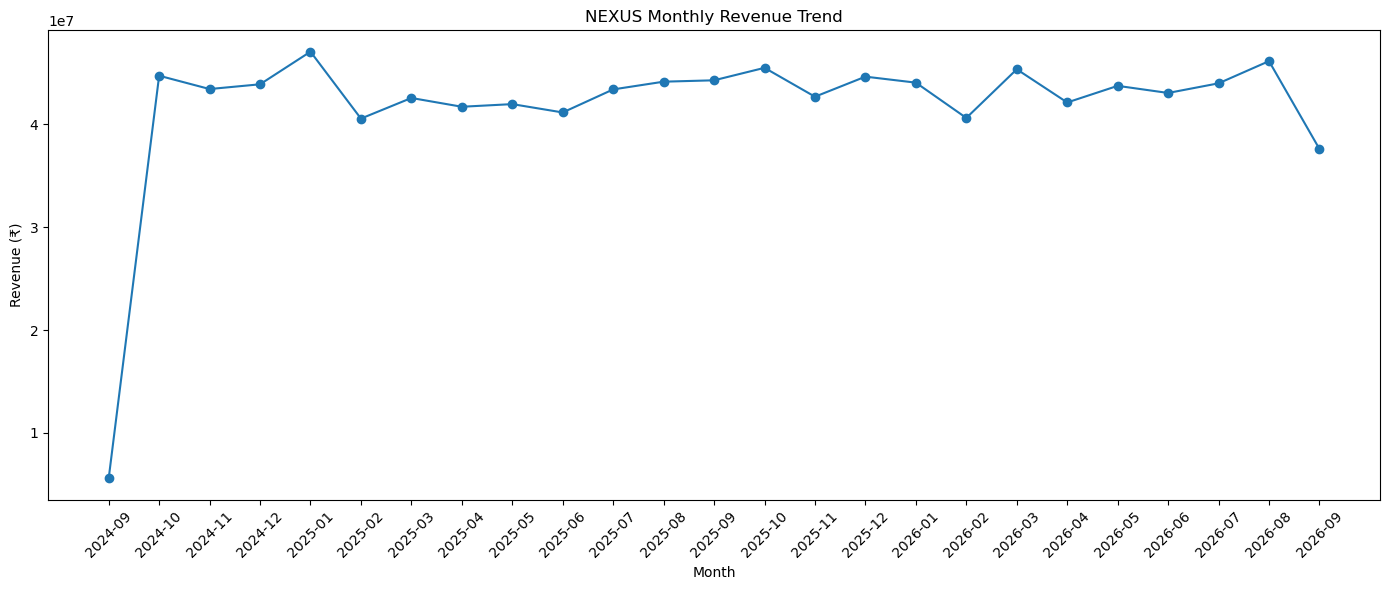

In [15]:
# Monthly Revenue Chart

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["total_amount"],
    marker="o"
)

plt.title("NEXUS Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# Revenue by Product Category

category_data = order_items.merge(
    products[["product_id", "category"]],
    on="product_id",
    how="left"
)

category_data["revenue"] = (
    category_data["unit_price"] *
    category_data["quantity"]
)

category_revenue = (
    category_data
    .groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue)

category
Electronics    1.443182e+09
Fashion        1.386931e+09
Sports         1.237398e+09
Home           1.155948e+09
Beauty         9.570804e+08
Name: revenue, dtype: float64


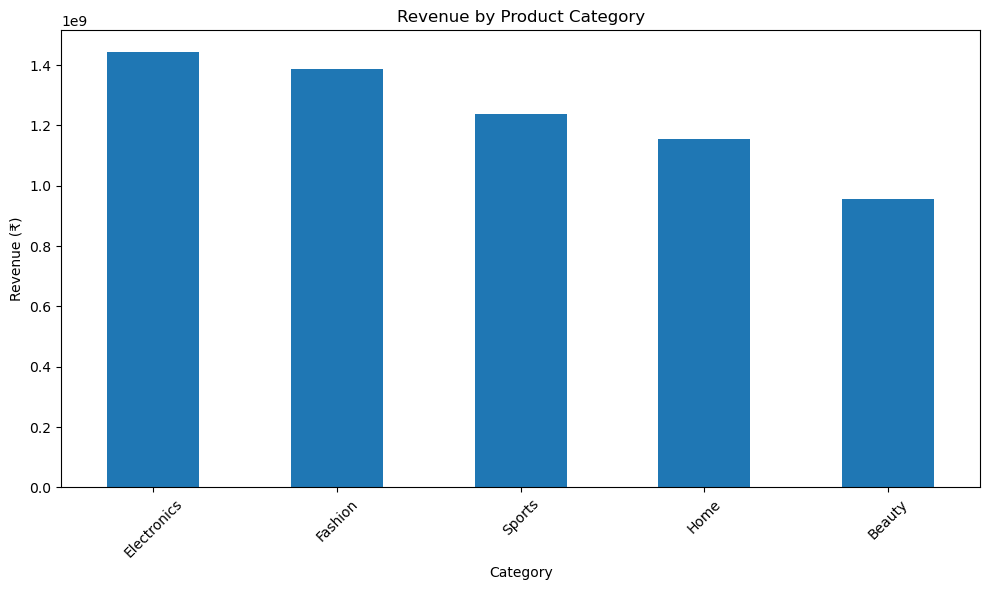

In [17]:
# Revenue by Product Category Chart

plt.figure(figsize=(10, 6))

category_revenue.plot(
    kind="bar"
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# Top 10 Products by Revenue

product_revenue = (
    order_items
    .merge(
        products[["product_id", "product_name"]],
        on="product_id",
        how="left"
    )
)

product_revenue["revenue"] = (
    product_revenue["unit_price"] *
    product_revenue["quantity"]
)

top_products = (
    product_revenue
    .groupby(
        ["product_id", "product_name"]
    )["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

product_id  product_name                              
230         Multi-lateral empowering productivity         31464430.62
113         Diverse transitional knowledgebase            30951602.85
296         Compatible cohesive customer loyalty          30166578.00
210         Balanced transitional standardization         29331307.89
38          Configurable zero tolerance implementation    28555014.60
262         Cross-group exuding complexity                27900144.67
355         Team-oriented intangible matrix               27721290.96
286         Cross-group fault-tolerant hardware           27313815.83
36          Up-sized transitional Local Area Network      26778844.48
83          Monitored object-oriented product             26553438.52
Name: revenue, dtype: float64


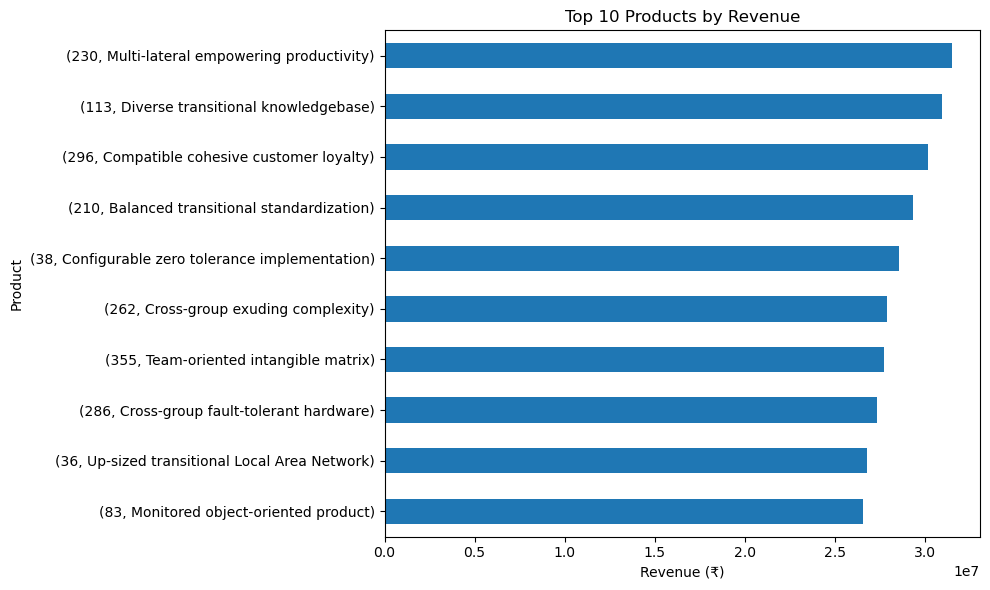

In [19]:
# Top 10 Products Revenue Chart

top_products.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (₹)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [20]:
# Revenue by Customer Segment

segment_data = orders.merge(
    customers[["customer_id", "customer_segment"]],
    on="customer_id",
    how="left"
)

segment_data = segment_data[
    segment_data["order_status"] != "Cancelled"
]

segment_revenue = (
    segment_data
    .groupby("customer_segment")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_revenue)

customer_segment
Premium    3.531462e+08
VIP        3.476470e+08
Regular    3.435207e+08
Name: total_amount, dtype: float64


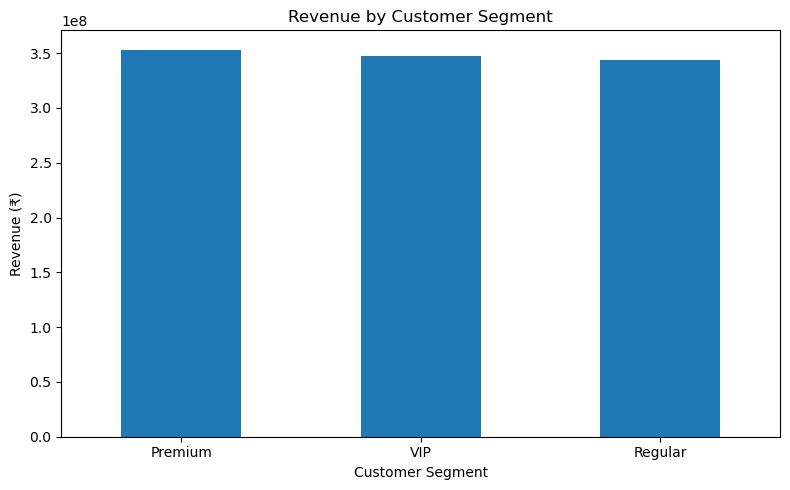

In [21]:
# Customer Segment Revenue Chart

segment_revenue.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
# Revenue by Warehouse

warehouse_data = orders.merge(
    warehouses[[
        "warehouse_id",
        "warehouse_name",
        "city"
    ]],
    on="warehouse_id",
    how="left"
)

warehouse_data = warehouse_data[
    warehouse_data["order_status"] != "Cancelled"
]

warehouse_revenue = (
    warehouse_data
    .groupby(
        ["warehouse_id", "warehouse_name", "city"]
    )["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

print(warehouse_revenue)

warehouse_id  warehouse_name  city         
19            Warehouse 19    Bhavnagar        55007662.56
16            Warehouse 16    South Dumdum     54026161.90
4             Warehouse 4     New Delhi        53916471.66
5             Warehouse 5     Udupi            53637155.56
9             Warehouse 9     Patna            53513535.22
6             Warehouse 6     Gwalior          53471212.40
2             Warehouse 2     Durgapur         53319170.00
20            Warehouse 20    Pondicherry      52998018.85
15            Warehouse 15    Karawal Nagar    52841105.54
7             Warehouse 7     South Dumdum     52784729.72
11            Warehouse 11    Malegaon         52286667.03
10            Warehouse 10    Guna             51886204.92
17            Warehouse 17    Raichur          51567352.55
12            Warehouse 12    Hindupur         51483920.01
18            Warehouse 18    Satara           50870832.83
8             Warehouse 8     Dindigul         50731519.31
13          

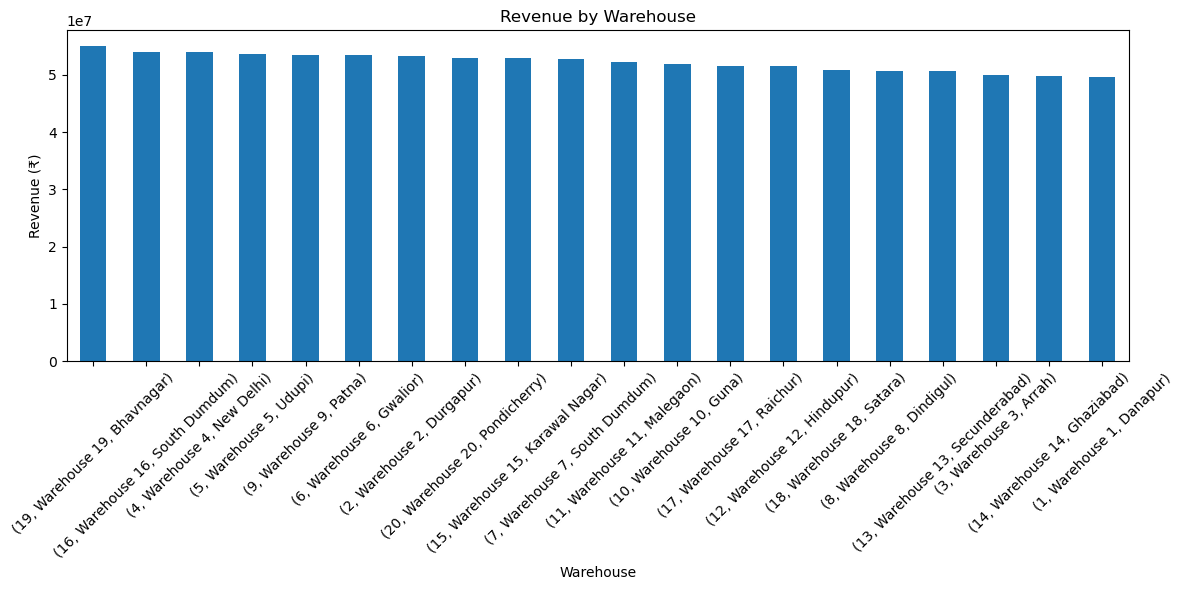

In [23]:
# Warehouse Revenue Chart

warehouse_revenue.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Revenue by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# Inventory Stockout Risk

inventory_risk = inventory[
    inventory["stock_quantity"] <= inventory["reorder_level"]
].copy()

inventory_risk = inventory_risk.merge(
    products[
        ["product_id", "product_name", "category"]
    ],
    on="product_id",
    how="left"
)

print(f"At-Risk Inventory Records: {len(inventory_risk):,}")

inventory_risk[
    [
        "product_id",
        "product_name",
        "category",
        "warehouse_id",
        "stock_quantity",
        "reorder_level"
    ]
].head(20)

At-Risk Inventory Records: 1,288


,product_id,product_name,category,warehouse_id,stock_quantity,reorder_level
0,1,Mandatory hybrid Internet solution,Sports,14,46,152
1,1,Mandatory hybrid Internet solution,Sports,15,96,100
2,2,Monitored impactful open architecture,Sports,2,128,189
3,2,Monitored impactful open architecture,Sports,18,48,195
4,3,Right-sized human-resource function,Sports,4,82,178
5,3,Right-sized human-resource function,Sports,8,27,143
6,3,Right-sized human-resource function,Sports,11,69,198
7,3,Right-sized human-resource function,Sports,12,56,72
8,3,Right-sized human-resource function,Sports,15,2,172
9,4,Profound modular interface,Sports,1,10,172


category
Electronics    319
Fashion        272
Sports         262
Home           246
Beauty         189
dtype: int64


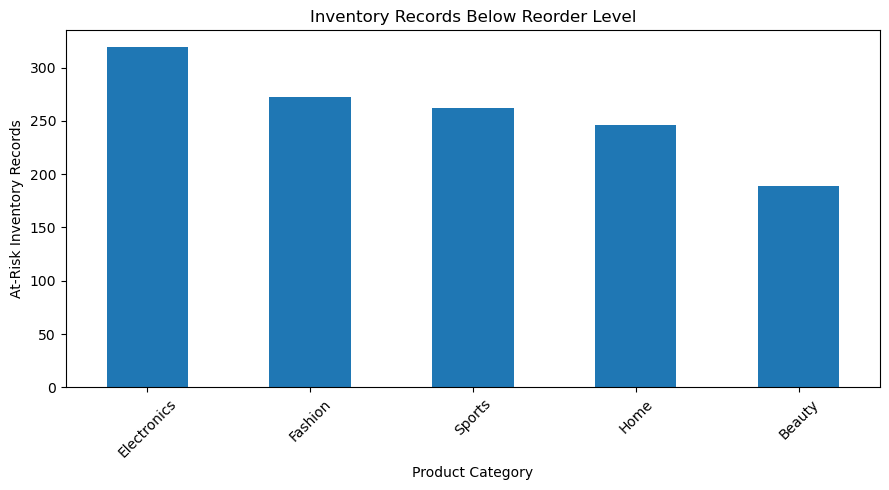

In [25]:
# Inventory Risk by Category

risk_by_category = (
    inventory_risk
    .groupby("category")
    .size()
    .sort_values(ascending=False)
)

print(risk_by_category)

risk_by_category.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Inventory Records Below Reorder Level")
plt.xlabel("Product Category")
plt.ylabel("At-Risk Inventory Records")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
# Delivery Performance by Carrier

carrier_performance = (
    deliveries
    .groupby("carrier")
    .agg(
        total_deliveries=("delivery_id", "count"),
        delayed_deliveries=(
            "delivery_delay_days",
            lambda x: (x > 0).sum()
        ),
        average_delay_days=(
            "delivery_delay_days",
            "mean"
        )
    )
)

carrier_performance["delay_rate"] = (
    carrier_performance["delayed_deliveries"]
    / carrier_performance["total_deliveries"]
    * 100
)

carrier_performance = carrier_performance.sort_values(
    "delay_rate",
    ascending=False
)

print(carrier_performance)

              total_deliveries  delayed_deliveries  average_delay_days  \
carrier                                                                  
Ecom Express              9956                5737            1.450080   
Delhivery                 9973                5692            1.422842   
Blue Dart                 9906                5648            1.435897   
XpressBees               10114                5743            1.427131   
DTDC                     10051                5703            1.409014   

              delay_rate  
carrier                   
Ecom Express   57.623544  
Delhivery      57.074100  
Blue Dart      57.015950  
XpressBees     56.782677  
DTDC           56.740623  


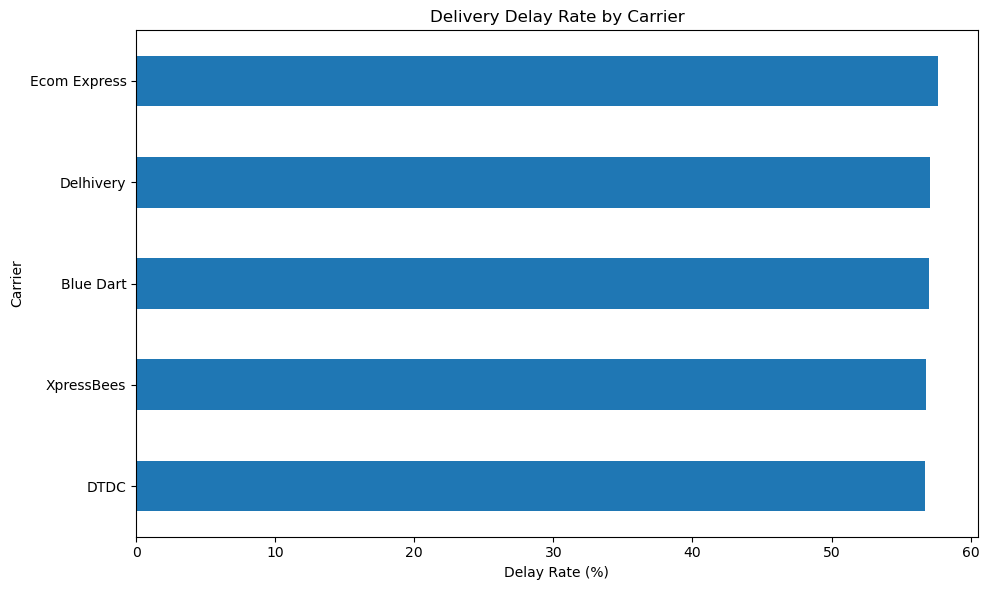

In [27]:
# Carrier Delay Rate Chart

carrier_performance["delay_rate"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Delivery Delay Rate by Carrier")
plt.xlabel("Delay Rate (%)")
plt.ylabel("Carrier")

plt.tight_layout()
plt.show()

In [28]:
# Return Reasons Analysis

return_reasons = (
    returns
    .groupby("return_reason")
    .agg(
        return_count=("return_id", "count"),
        refund_amount=("refund_amount", "sum")
    )
    .sort_values("return_count", ascending=False)
)

print(return_reasons)

               return_count  refund_amount
return_reason                             
Quality Issue           821    21479562.33
Changed Mind            816    21946142.52
Damaged                 805    20764148.79
Wrong Product           794    20025906.93
Size Issue              764    19851188.25


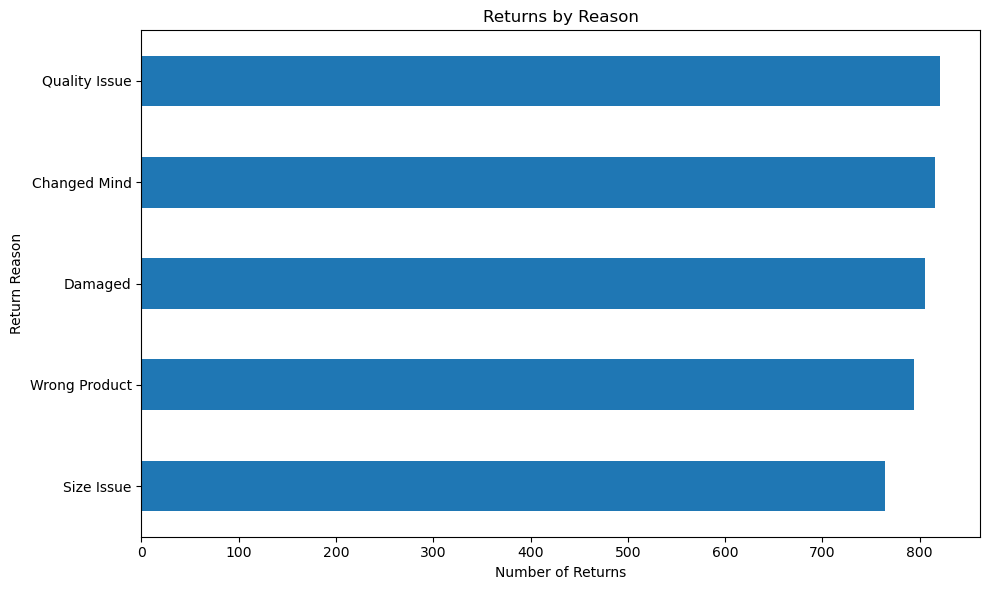

In [29]:
# Return Reasons Chart

return_reasons["return_count"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Returns by Reason")
plt.xlabel("Number of Returns")
plt.ylabel("Return Reason")

plt.tight_layout()
plt.show()

In [30]:
# Payment Method Analysis

payment_analysis = (
    payments
    .groupby("payment_method")
    .agg(
        total_payments=("payment_id", "count"),
        total_amount=("amount", "sum")
    )
    .sort_values("total_amount", ascending=False)
)

print(payment_analysis)

                  total_payments  total_amount
payment_method                                
Debit Card                 10009  2.529490e+08
Cash on Delivery           10023  2.515871e+08
Net Banking                 9997  2.498936e+08
UPI                        10014  2.490665e+08
Credit Card                 9957  2.477706e+08


In [31]:
# Payment Status Analysis

payment_status_analysis = (
    payments
    .groupby("payment_status")
    .agg(
        payment_count=("payment_id", "count"),
        total_amount=("amount", "sum")
    )
    .sort_values("payment_count", ascending=False)
)

print(payment_status_analysis)

                payment_count  total_amount
payment_status                             
Paid                    29933  7.486474e+08
Failed                  10038  2.521495e+08
Pending                 10029  2.504700e+08


In [32]:
# Payment Failure Rate

total_payments = len(payments)

failed_payments = (
    payments["payment_status"] == "Failed"
).sum()

payment_failure_rate = (
    failed_payments / total_payments
) * 100

print(f"Total Payments: {total_payments:,}")
print(f"Failed Payments: {failed_payments:,}")
print(f"Payment Failure Rate: {payment_failure_rate:.2f}%")

Total Payments: 50,000
Failed Payments: 10,038
Payment Failure Rate: 20.08%
